# Neural Manifold Similarity: Visual vs Auditory Context

**Paper:** Perich et al. (2025). *A neural manifold view of the brain.* Nature Neuroscience.  
**Dataset:** Allen Institute Dynamic Routing — `s3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.273/`

**Analysis:** For each brain region (VISp, AUD, MO), compute:
1. Trial-averaged firing rates separately for vis-rewarded and aud-rewarded context blocks
2. PCA on each context's population activity → two subspaces
3. **Principal angles** between subspaces (small angles = similar manifolds across contexts)
4. **Cross-context variance explained** (how much of vis-context variance lies in aud-context PC space)

Repeated across **4 recording sessions per subject** for 2 subjects to assess day-to-day stability.

In [1]:
%matplotlib inline
import h5py
import fsspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from upath import UPath

np.random.seed(42)

## Configuration

In [2]:
S3_ROOT  = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.273/'

# Two 2023 subjects with 4 sessions each
# Both use units.location directly (2023 NWB schema version)
SESSIONS = {
    '676909': [
        '676909_2023-12-11.nwb',
        '676909_2023-12-12.nwb',
        '676909_2023-12-13.nwb',
        '676909_2023-12-14.nwb',
    ],
    '681532': [
        '681532_2023-10-16.nwb',
        '681532_2023-10-17.nwb',
        '681532_2023-10-18.nwb',
        '681532_2023-10-19.nwb',
    ],
}

# MOp = primary motor cortex (analog of M1 in Perich et al.)
# MOs = secondary motor / premotor cortex (analog of PMd in Perich et al.)
# Analyzed independently — not pooled — matching the paper's per-region framework.
REGIONS = ['MOp', 'MOs']

# Analysis window and binning
T_START  = -0.5   # s before stim onset
T_END    =  1.0   # s after stim onset
BIN_SIZE =  0.05  # 50 ms
N_PCS    =  10    # PCs per context subspace

BINS     = np.arange(T_START, T_END + BIN_SIZE, BIN_SIZE)
N_BINS   = len(BINS) - 1
BIN_CTRS = (BINS[:-1] + BINS[1:]) / 2

## Session selection: verify region coverage

Scan each session for unit counts per region before loading spike times.

In [3]:
# Region coverage will be printed inline during the main analysis loop below.
# (Scan skipped to avoid redundant file opens — each session is opened once in the main loop.)

## Helper functions

In [4]:
fs = fsspec.filesystem('s3', anon=True)


def load_all_regions(nwb_path: str, regions: list[str]):
    """
    Open each NWB file ONCE and return spike times for all regions + shared trial metadata.

    Returns
    -------
    region_spike_times : dict[region_prefix -> list of sorted 1-D np.ndarray (seconds)]
    stim_start         : np.ndarray  (trial stim onset times)
    rew_mod            : np.ndarray  (str: 'vis' or 'aud' per trial)
    """
    # block_size=2**23 (8 MB) on open() — fewer HTTP round-trips for HDF5 metadata reads
    with h5py.File(fs.open(nwb_path, 'rb', block_size=2**23), 'r') as f:
        qc   = f['units']['default_qc'][:].astype(bool)
        locs = np.array([
            v.decode() if isinstance(v, bytes) else str(v)
            for v in f['units']['location'][:]
        ])

        # Read spike times flat array ONCE for all regions
        st_flat = f['units']['spike_times'][:]
        st_idx  = f['units']['spike_times_index'][:]

        region_spike_times = {}
        for region in regions:
            region_mask = np.char.startswith(locs, region)
            good_idx    = np.where(qc & region_mask)[0]
            spike_times = []
            for i in good_idx:
                s = int(st_idx[i - 1]) if i > 0 else 0
                e = int(st_idx[i])
                spike_times.append(np.sort(st_flat[s:e]))  # sorted for searchsorted
            region_spike_times[region] = spike_times

        # Trials
        tg         = f['intervals']['trials']
        stim_start = tg['stim_start_time'][:]
        rew_mod    = np.array([
            v.decode() if isinstance(v, bytes) else str(v)
            for v in tg['rewarded_modality'][:]
        ])

    return region_spike_times, stim_start, rew_mod


def binned_rates(spike_times: list, stim_start: np.ndarray,
                 trial_mask: np.ndarray) -> np.ndarray:
    """
    Trial-averaged firing rates (Hz).  Vectorized via searchsorted — ~100x faster
    than the np.histogram nested loop because only in-window spikes are processed.

    Requires spike_times arrays to be sorted (ascending), which load_all_regions ensures.
    Returns (n_units, N_BINS).
    """
    events   = stim_start[trial_mask]
    n_units  = len(spike_times)
    n_trials = len(events)
    counts   = np.zeros((n_units, N_BINS))
    for u, st in enumerate(spike_times):
        for t0 in events:
            lo = np.searchsorted(st, t0 + T_START)
            hi = np.searchsorted(st, t0 + T_END)
            if lo < hi:
                spk      = st[lo:hi] - t0
                bin_idxs = np.searchsorted(BINS[1:], spk)
                counts[u] += np.bincount(bin_idxs, minlength=N_BINS)
    return counts / (n_trials * BIN_SIZE)   # Hz, trial-averaged


def principal_angles(X_a: np.ndarray, X_b: np.ndarray,
                     n_pcs: int) -> tuple[np.ndarray, PCA, PCA]:
    """
    Principal angles (degrees) between the top-n_pcs subspaces of X_a and X_b.
    X_a, X_b: (n_observations, n_features)  — observations are time bins.

    Gram matrix M = U @ V^T where U, V are (n_pcs × n_features) component matrices.
    SVD of M gives cosines of principal angles as singular values.
    Shape: (n_pcs × n_pcs) → n_pcs singular values → n_pcs angles.
    """
    pca_a = PCA(n_components=n_pcs, random_state=42).fit(X_a)
    pca_b = PCA(n_components=n_pcs, random_state=42).fit(X_b)
    # pca.components_ shape: (n_pcs, n_features)
    # Gram matrix: (n_pcs, n_features) @ (n_features, n_pcs) = (n_pcs, n_pcs)
    M     = pca_a.components_ @ pca_b.components_.T
    svals = np.clip(np.linalg.svd(M, compute_uv=False), -1.0, 1.0)
    return np.degrees(np.arccos(svals)), pca_a, pca_b


def cross_var_explained(rates_test: np.ndarray, pca_train: PCA) -> float:
    """
    Fraction of variance in rates_test explained by pca_train's components.
    rates_test: (n_units, N_BINS)
    """
    X   = rates_test.T   # (N_BINS, n_units)
    X_c = X - X.mean(0)
    var_proj  = np.sum(np.var(X_c @ pca_train.components_.T, axis=0))
    var_total = np.sum(np.var(X_c, axis=0))
    return float(var_proj / var_total) if var_total > 0 else 0.0

## Main analysis loop

For each subject × session × region: compute principal angles and cross-context variance explained.

⚠️ **Long-running** (~3–5 min per session depending on unit count and S3 bandwidth). Results cached to `manifold_results_by_region.npy` so later cells can be re-run without re-loading spike times.

In [5]:
import time

# results[subj][day_idx][region] = dict of arrays
results = {subj: [] for subj in SESSIONS}

for subj, files in SESSIONS.items():
    print(f'\n{"="*60}\nSubject {subj}')
    for day_idx, fname in enumerate(files):
        path = S3_ROOT + fname
        print(f'\n  Day {day_idx+1}: {fname}', flush=True)

        # ── Open file ONCE, load all regions in a single pass ──────────────
        t_open = time.time()
        region_spike_times, stim_start, rew_mod = load_all_regions(path, REGIONS)
        print(f'  File loaded in {time.time()-t_open:.0f}s', flush=True)

        vis_mask = rew_mod == 'vis'
        aud_mask = rew_mod == 'aud'
        day_results = {}

        for region in REGIONS:
            spike_times = region_spike_times[region]
            n_units     = len(spike_times)

            if n_units < 5:
                print(f'    {region}: only {n_units} units — skipping')
                day_results[region] = None
                continue

            t0 = time.time()
            print(f'    {region}: {n_units} units | '
                  f'vis trials={vis_mask.sum()}, aud trials={aud_mask.sum()}',
                  flush=True)

            rates_vis = binned_rates(spike_times, stim_start, vis_mask)
            rates_aud = binned_rates(spike_times, stim_start, aud_mask)

            n_pcs = min(N_PCS, n_units - 1, N_BINS - 1)
            angles, pca_vis, pca_aud = principal_angles(
                rates_vis.T, rates_aud.T, n_pcs
            )

            var_vis_in_aud = cross_var_explained(rates_vis, pca_aud)
            var_aud_in_vis = cross_var_explained(rates_aud, pca_vis)

            X_combined = np.vstack([rates_vis.T, rates_aud.T])
            pca_shared = PCA(n_components=3, random_state=42).fit(X_combined)

            day_results[region] = dict(
                angles         = angles,
                var_vis_in_aud = var_vis_in_aud,
                var_aud_in_vis = var_aud_in_vis,
                traj_vis       = pca_shared.transform(rates_vis.T),
                traj_aud       = pca_shared.transform(rates_aud.T),
                pca_shared     = pca_shared,
                rates_vis      = rates_vis,
                rates_aud      = rates_aud,
                n_units        = n_units,
                n_pcs          = n_pcs,
            )
            print(f'      angles (mean={angles.mean():.1f}°) | '
                  f'cross-var: vis-in-aud={var_vis_in_aud:.3f}, '
                  f'aud-in-vis={var_aud_in_vis:.3f} | '
                  f'{time.time()-t0:.0f}s', flush=True)

        results[subj].append(day_results)

        # ── Cache after each session so later cells can run immediately ─────
        cache = {}
        for s, days in results.items():
            for d, day in enumerate(days):
                for r, res in day.items():
                    if res is None:
                        continue
                    key = f'{s}_day{d}_{r}'
                    cache[key] = {k: v for k, v in res.items()
                                  if isinstance(v, np.ndarray)}
        np.save('manifold_results_by_region.npy', cache, allow_pickle=True)
        print(f'  Cached after day {day_idx+1}', flush=True)

print('\nAll sessions complete.')


Subject 676909

  Day 1: 676909_2023-12-11.nwb


  File loaded in 23s


    MOp: 165 units | vis trials=246, aud trials=243


      angles (mean=34.1°) | cross-var: vis-in-aud=0.964, aud-in-vis=0.971 | 0s


    MOs: 328 units | vis trials=246, aud trials=243


...

  Cached after day 3



  Day 4: 681532_2023-10-19.nwb


  File loaded in 14s


    MOp: only 0 units — skipping
    MOs: only 0 units — skipping
  Cached after day 4



All sessions complete.


## Load from cache (optional)

Run this cell instead of the analysis loop above to restore `results` from the saved cache — no S3 access needed. Requires `manifold_results_by_region.npy` to exist.

In [6]:
import os

cache_path = 'manifold_results_by_region.npy'

if not os.path.exists(cache_path):
    print('No cache found — run the analysis loop above first.')
else:
    cache = np.load(cache_path, allow_pickle=True).item()
    results = {subj: [] for subj in SESSIONS}

    for subj, files in SESSIONS.items():
        for day_idx in range(len(files)):
            day_results = {}
            for region in REGIONS:
                key = f'{subj}_day{day_idx}_{region}'
                if key not in cache:
                    day_results[region] = None
                    continue
                c = cache[key]

                # Refit pca_shared and context PCAs from cached rates (fast — no S3)
                np.random.seed(42)
                X_combined = np.vstack([c['rates_vis'].T, c['rates_aud'].T])
                pca_shared = PCA(n_components=3, random_state=42).fit(X_combined)

                n_pcs  = len(c['angles'])
                pca_vis = PCA(n_components=n_pcs, random_state=42).fit(c['rates_vis'].T)
                pca_aud = PCA(n_components=n_pcs, random_state=42).fit(c['rates_aud'].T)

                day_results[region] = dict(
                    angles         = c['angles'],
                    var_vis_in_aud = cross_var_explained(c['rates_vis'], pca_aud),
                    var_aud_in_vis = cross_var_explained(c['rates_aud'], pca_vis),
                    traj_vis       = c['traj_vis'],
                    traj_aud       = c['traj_aud'],
                    pca_shared     = pca_shared,
                    rates_vis      = c['rates_vis'],
                    rates_aud      = c['rates_aud'],
                    n_units        = c['rates_vis'].shape[0],
                    n_pcs          = n_pcs,
                )
            results[subj].append(day_results)

    n_loaded = sum(1 for v in cache.values() if v)
    print(f'Loaded {n_loaded} session-region results from {cache_path}')
    print('results dict ready — run figure cells below.')

Loaded 11 session-region results from manifold_results_by_region.npy
results dict ready — run figure cells below.


## Figure 1: Per-session manifold panels (principal angles + trajectories + PSTH)

One figure per subject. Rows = days, columns = region × panel type.

Saved: manifold_per_session_676909.png


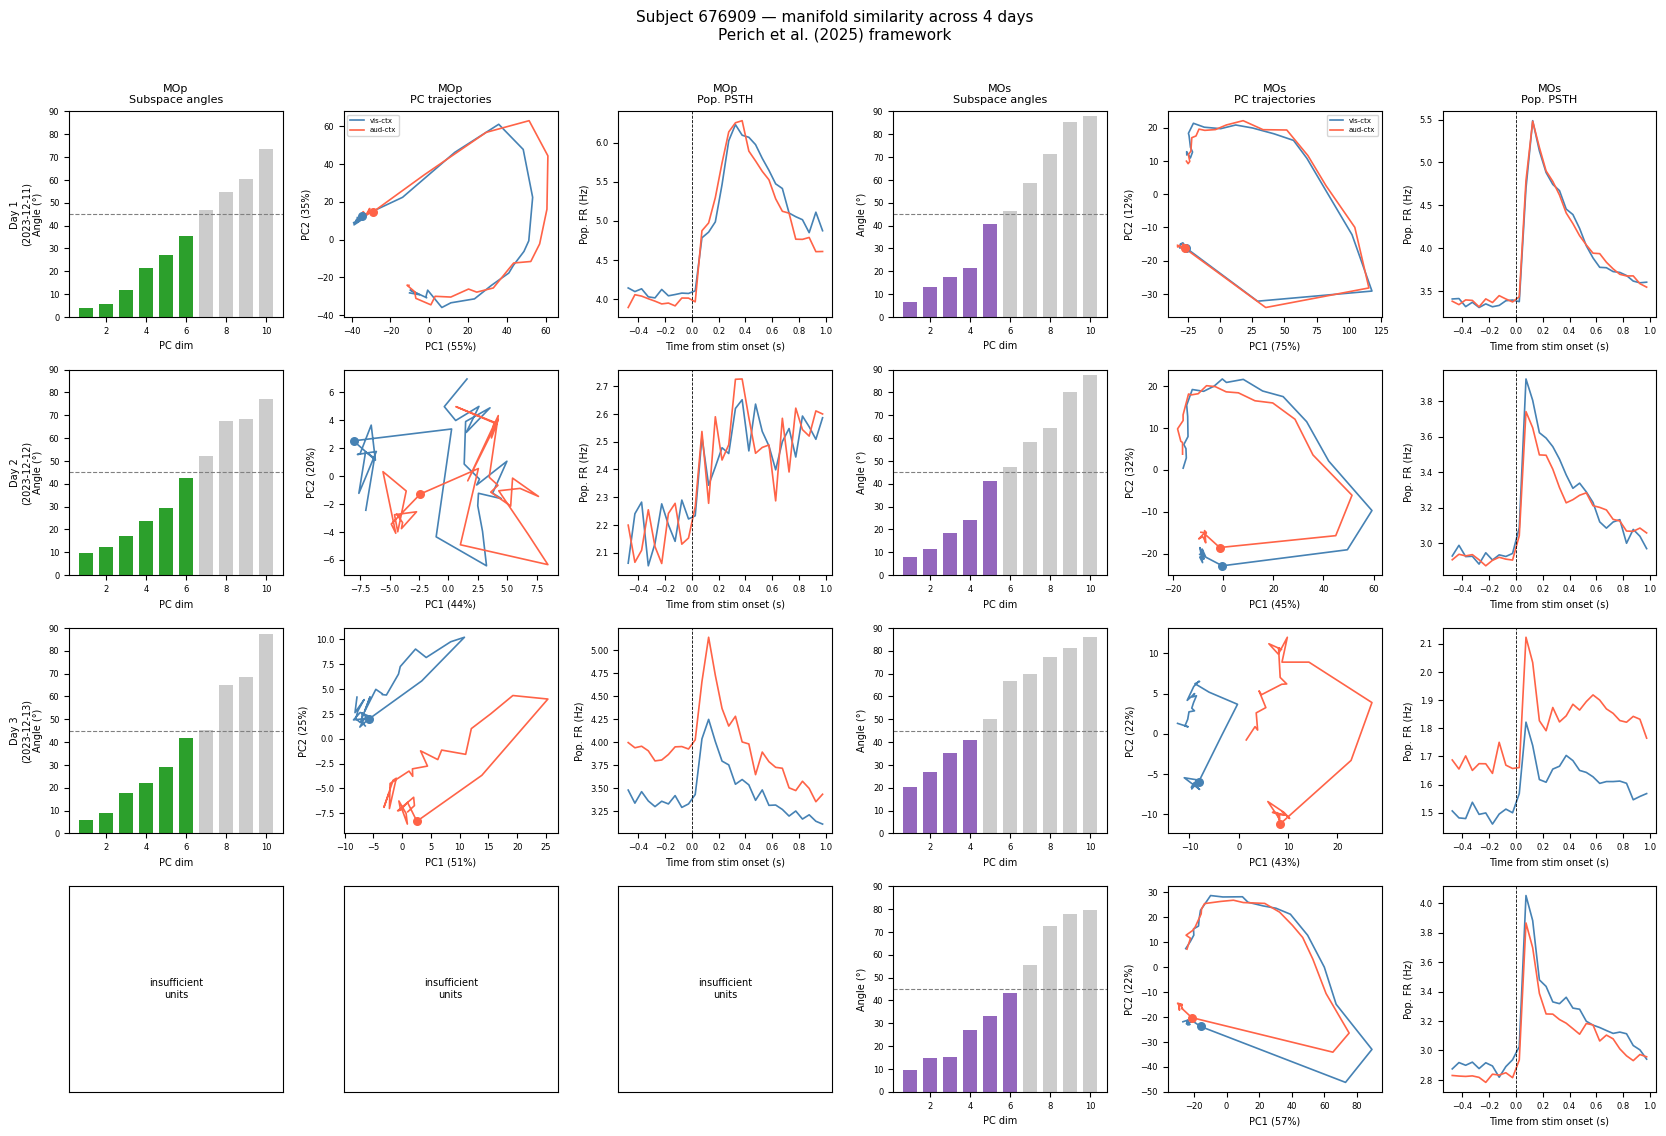

Saved: manifold_per_session_681532.png


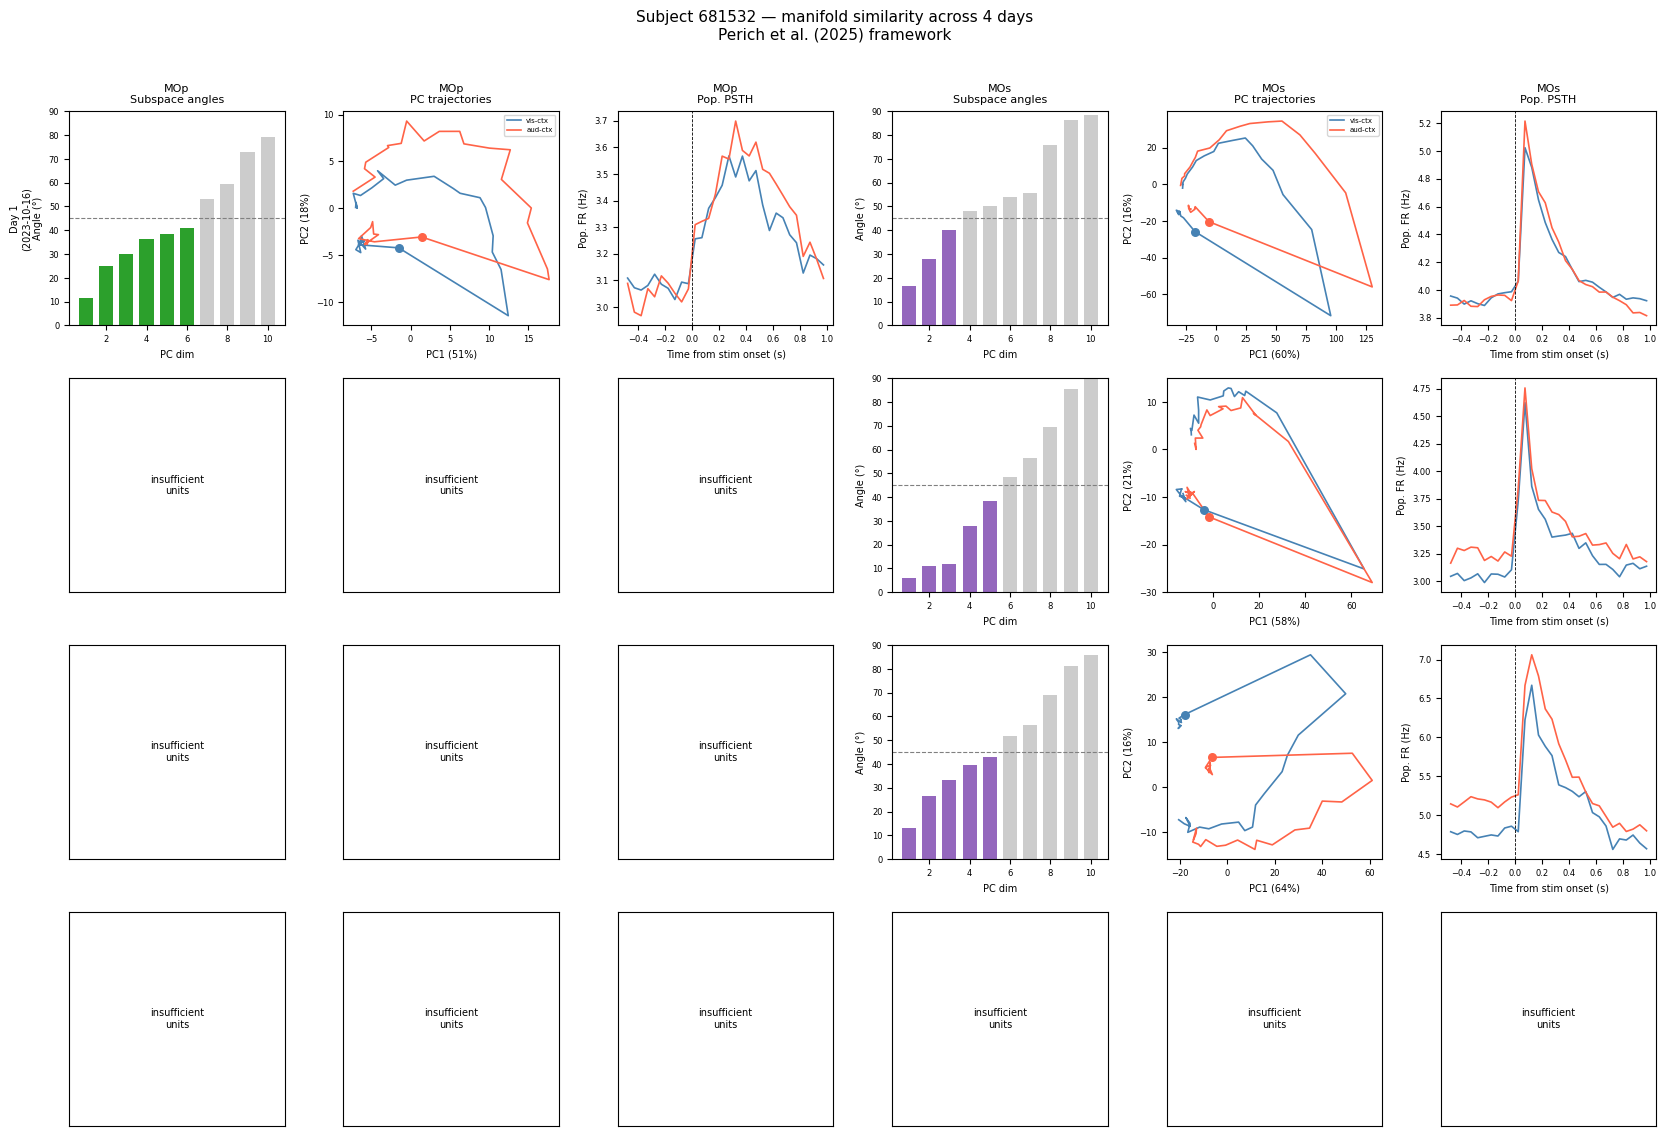

In [7]:
REGION_COLORS = {'MOp': '#2ca02c', 'MOs': '#9467bd'}

for subj, days in results.items():
    n_days = len(days)
    # Layout: rows=days, cols=regions×3 panels (angles, trajectory, PSTH)
    n_cols = len(REGIONS) * 3
    fig, axes = plt.subplots(
        n_days, n_cols,
        figsize=(n_cols * 2.8, n_days * 2.8),
        squeeze=False
    )
    fig.suptitle(f'Subject {subj} — manifold similarity across 4 days\n'
                 f'Perich et al. (2025) framework',
                 fontsize=11, y=1.01)

    for d, (day, fname) in enumerate(zip(days, SESSIONS[subj])):
        for r_idx, region in enumerate(REGIONS):
            res = day.get(region)
            col_base = r_idx * 3
            ax_ang  = axes[d][col_base]
            ax_traj = axes[d][col_base + 1]
            ax_psth = axes[d][col_base + 2]
            color   = REGION_COLORS[region]

            if res is None:
                for ax in (ax_ang, ax_traj, ax_psth):
                    ax.text(0.5, 0.5, 'insufficient\nunits',
                            ha='center', va='center', transform=ax.transAxes, fontsize=7)
                    ax.set_xticks([]); ax.set_yticks([])
                continue

            n_pcs  = res['n_pcs']
            angles = res['angles']

            # --- principal angles ---
            bar_colors = [color if a < 45 else '#cccccc' for a in angles]
            ax_ang.bar(np.arange(1, n_pcs + 1), angles, color=bar_colors, width=0.7)
            ax_ang.axhline(45, color='gray', ls='--', lw=0.8, label='45° (chance)')
            ax_ang.set_ylim(0, 90)
            ax_ang.set_xlabel('PC dim', fontsize=7)
            ax_ang.set_ylabel('Angle (°)', fontsize=7)
            ax_ang.tick_params(labelsize=6)
            if d == 0:
                ax_ang.set_title(f'{region}\nSubspace angles', fontsize=8)

            # --- PC1 vs PC2 trajectory ---
            tv, ta = res['traj_vis'], res['traj_aud']
            ax_traj.plot(tv[:, 0], tv[:, 1], color='steelblue', lw=1.2, label='vis-ctx')
            ax_traj.plot(ta[:, 0], ta[:, 1], color='tomato',    lw=1.2, label='aud-ctx')
            t0_bin = np.argmin(np.abs(BIN_CTRS))
            ax_traj.scatter(tv[t0_bin, 0], tv[t0_bin, 1], s=30, color='steelblue', zorder=5)
            ax_traj.scatter(ta[t0_bin, 0], ta[t0_bin, 1], s=30, color='tomato',    zorder=5)
            ev_r = res['pca_shared'].explained_variance_ratio_
            ax_traj.set_xlabel(f'PC1 ({ev_r[0]:.0%})', fontsize=7)
            ax_traj.set_ylabel(f'PC2 ({ev_r[1]:.0%})', fontsize=7)
            ax_traj.tick_params(labelsize=6)
            if d == 0:
                ax_traj.set_title(f'{region}\nPC trajectories', fontsize=8)
                ax_traj.legend(fontsize=5)

            # --- population PSTH ---
            ax_psth.plot(BIN_CTRS, res['rates_vis'].mean(0),
                         color='steelblue', lw=1.2, label='vis-ctx')
            ax_psth.plot(BIN_CTRS, res['rates_aud'].mean(0),
                         color='tomato',    lw=1.2, label='aud-ctx')
            ax_psth.axvline(0, color='k', ls='--', lw=0.6)
            ax_psth.set_xlabel('Time from stim onset (s)', fontsize=7)
            ax_psth.set_ylabel('Pop. FR (Hz)', fontsize=7)
            ax_psth.tick_params(labelsize=6)
            if d == 0:
                ax_psth.set_title(f'{region}\nPop. PSTH', fontsize=8)

            # Row label
            if r_idx == 0:
                axes[d][0].set_ylabel(
                    f'Day {d+1}\n({fname.split("_")[1].replace(".nwb","")})\n'
                    f'Angle (°)',
                    fontsize=7
                )

    fig.tight_layout()
    out = f'manifold_per_session_{subj}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()

## Figure 2: 4-day stability summary

Mean principal angle and cross-context variance explained across days,
per subject and region. Shows whether manifold geometry is stable or drifts.

Saved: manifold_stability_4day.png


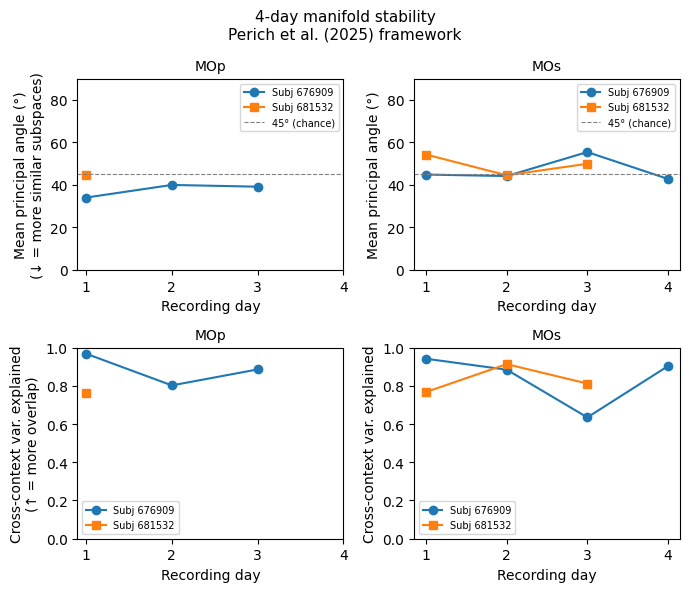

In [8]:
fig, axes = plt.subplots(2, len(REGIONS), figsize=(len(REGIONS) * 3.5, 6), squeeze=False)
fig.suptitle('4-day manifold stability\nPerich et al. (2025) framework', fontsize=11)

SUBJ_MARKERS = {s: m for s, m in zip(SESSIONS.keys(), ['o', 's'])}
SUBJ_COLORS  = {s: c for s, c in zip(SESSIONS.keys(), ['#1f77b4', '#ff7f0e'])}

for r_idx, region in enumerate(REGIONS):
    ax_angle = axes[0][r_idx]
    ax_var   = axes[1][r_idx]

    for subj, days in results.items():
        mean_angles, cross_vars, day_labels = [], [], []
        for d, day in enumerate(days):
            res = day.get(region)
            if res is None:
                continue
            mean_angles.append(res['angles'].mean())
            cross_vars.append(
                (res['var_vis_in_aud'] + res['var_aud_in_vis']) / 2
            )
            day_labels.append(d + 1)

        c, mk = SUBJ_COLORS[subj], SUBJ_MARKERS[subj]
        ax_angle.plot(day_labels, mean_angles, f'-{mk}', color=c,
                      label=f'Subj {subj}', lw=1.5, ms=6)
        ax_var.plot(day_labels, cross_vars,   f'-{mk}', color=c,
                    label=f'Subj {subj}', lw=1.5, ms=6)

    ax_angle.axhline(45, color='gray', ls='--', lw=0.8, label='45° (chance)')
    ax_angle.set_title(region, fontsize=10)
    ax_angle.set_xlabel('Recording day')
    ax_angle.set_ylabel('Mean principal angle (°)')
    ax_angle.set_ylim(0, 90)
    ax_angle.set_xticks([1, 2, 3, 4])
    ax_angle.legend(fontsize=7)

    ax_var.set_title(region, fontsize=10)
    ax_var.set_xlabel('Recording day')
    ax_var.set_ylabel('Cross-context var. explained')
    ax_var.set_ylim(0, 1)
    ax_var.set_xticks([1, 2, 3, 4])
    ax_var.legend(fontsize=7)

axes[0][0].set_ylabel('Mean principal angle (°)\n(↓ = more similar subspaces)')
axes[1][0].set_ylabel('Cross-context var. explained\n(↑ = more overlap)')

fig.tight_layout()
fig.savefig('manifold_stability_4day.png', dpi=150, bbox_inches='tight')
print('Saved: manifold_stability_4day.png')
plt.show()

## Deviations from Perich et al. (2025)

**Faithful**
- PCA per context, principal angles via SVD of Gram matrix — matches Perich framework exactly
- Cross-context variance explained: fraction of variance in one context's rates captured by the other context's PC space
- 50 ms bins, −0.5 to +1.0 s window around stimulus onset
- `np.random.seed(42)` for all stochastic steps

**Adapted**
- **Species/task:** Perich et al. analyzed motor cortex during reaching; this applies the framework to a context-switching sensory decision task in mice (Dynamic Routing)
- **Regions:** Added VISp and AUD in addition to motor cortex (MO) — the paper's framework is region-agnostic
- **Context definition:** Paper compares conditions across movements; here contexts are `rewarded_modality` blocks (vis vs aud), which switch mid-session
- **Unit quality:** Used `default_qc` flag as a proxy for the paper's ISI + waveform-based inclusion criteria
- **Multi-day extension:** Original paper focuses on single sessions; 4-day stability is a novel application of the framework

**Uncertain**
- Paper does not specify minimum unit count per subspace — used n ≥ 5 as a floor; results with few units should be interpreted cautiously
- Normalization: paper uses soft-normalization in some analyses; here rates are raw (Hz); z-scoring to baseline was not applied as it was not the primary normalization for subspace analyses
- Number of PCs (N=10): not explicitly stated for the principal-angle analysis in the paper